### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [105]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [106]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [107]:
import yaml

In [108]:
# Notebook input parameters
SAVE_FIGURES = True
SAVE_TABLES = True
show_plots = False
folder_name = "XXX4weeks_1core___"

In [109]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [110]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [111]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [112]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [113]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [114]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]

In [115]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [116]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [117]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [118]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [119]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [120]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [121]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,6850.600000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,13701.200000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,20551.800000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,27402.400000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,2137.049865,0.000000,0.000000,2137.049865,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299140.224929,0.00,#4adbc8,Run of River,True,539.200000,0.000000,539.200000,2156.800000,808.800000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,1296.147198,1296.147198,1944.220796
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,2592.294395,2592.294395,3240.367994


### Generator Investment and Capacity Plots 

In [122]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


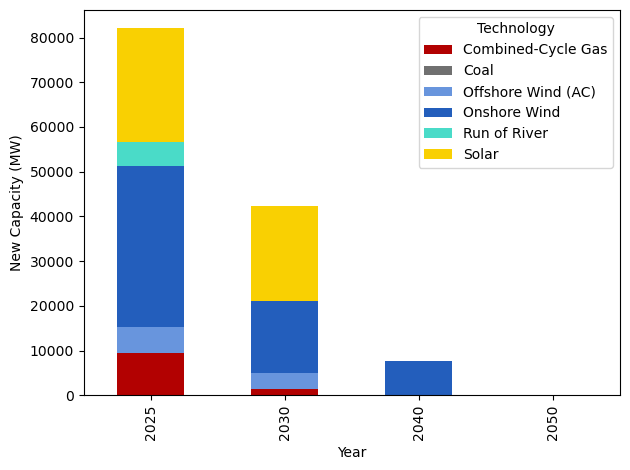

In [123]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


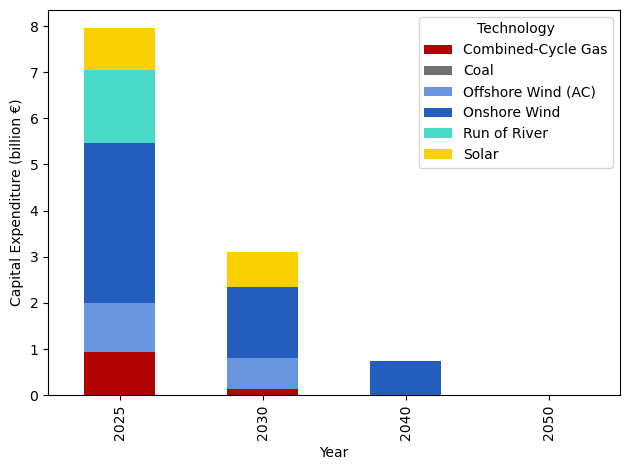

In [124]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


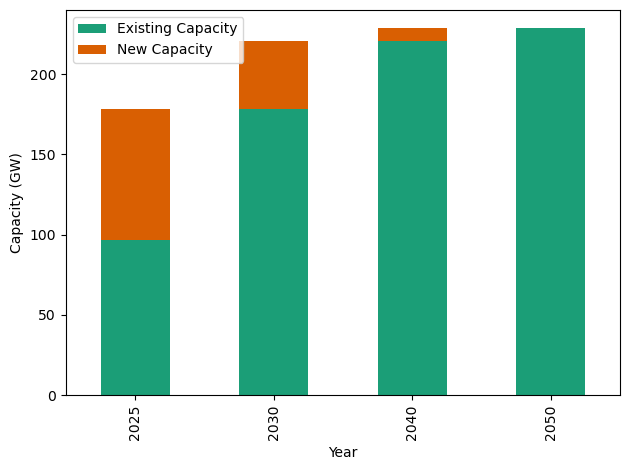

In [125]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


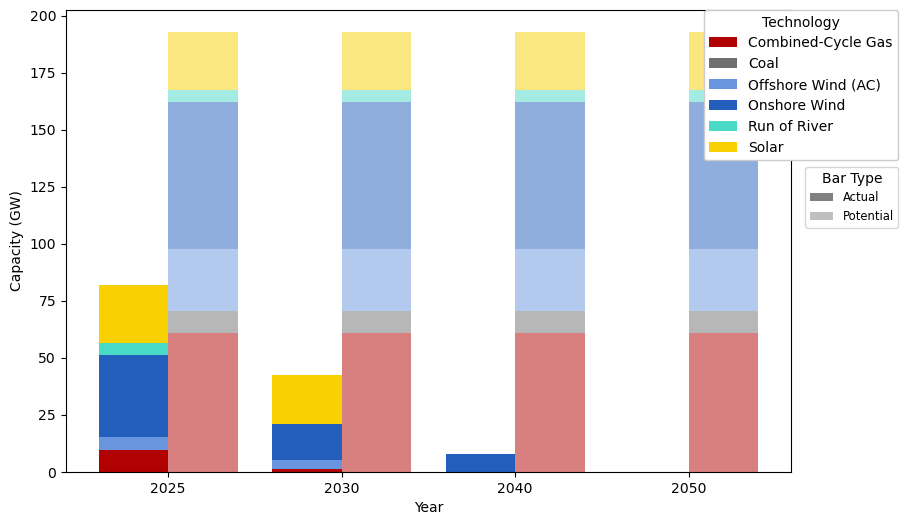

In [126]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [127]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,4.642504e+07,9.737656e+05,3.646754e+07,1.023460e+08,3.739784e+07,5.152083e+07
2030,3.278349e+07,8.319495e+05,3.885367e+07,1.080506e+08,3.739784e+07,7.738377e+07
2040,4.861161e+07,2.029698e+06,4.430422e+07,1.392734e+08,3.739784e+07,8.053204e+07
2050,5.867804e+07,2.670204e+06,4.689541e+07,1.486063e+08,3.739784e+07,8.105062e+07


In [128]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        4.642504e+07  9.737656e+05  3.646754e+07  1.023460e+08   
2030 NT        3.278349e+07  8.319495e+05  3.885367e+07  1.080506e+08   
2040 DE        1.840675e+07  8.013959e+05  1.535376e+07  4.881184e+07   
     GA        1.305487e+07  4.866223e+05  1.378322e+07  4.298137e+07   
     NT        1.714999e+07  7.416795e+05  1.516724e+07  4.748017e+07   
2050 DE        3.439874e+07  1.632199e+06  2.461384e+07  7.880588e+07   
     GA        2.427930e+07  1.038004e+06  2.228157e+07  6.980046e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        3.739784e+07  5.152083e+07  2.751310e+08  
2030 NT        3.739784e+07  7.738377e+07  2.953014e+08  
2040 DE        1.246595e+07  2.702073e+07  1.228604e+08  
     GA        1.246595e+07  2.654787e+07  1.093199e+08  
     NT        1.246595e+07  2.696345e+07  1.199685e+08  
2050 DE        1.869892e+07  4.070480e+07  1.988544e+08  
     GA        1.869892e+07  4.034583e+07  1.764441e+08

In [129]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,2.547589e+09,5.394366e+07,547013.119330,1.535189e+06,0.0,515208.289668,2.604130e+09
2030,1.799025e+09,4.608748e+07,582805.033413,1.620760e+06,0.0,773837.742949,1.848090e+09
2040,2.670042e+09,1.124391e+08,664563.305761,2.089101e+06,0.0,805320.403780,2.786040e+09
2050,3.226383e+09,1.479212e+08,703431.183130,2.229095e+06,0.0,810506.234358,3.378047e+09


In [130]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.642504e+07,9.737656e+05,3.646754e+07,1.023460e+08,3.739784e+07,5.152083e+07,2.751310e+08
2030,3.278349e+07,8.319495e+05,3.885367e+07,1.080506e+08,3.739784e+07,7.738377e+07,2.953014e+08
2040,4.861161e+07,2.029698e+06,4.430422e+07,1.392734e+08,3.739784e+07,8.053204e+07,3.521488e+08
2050,5.867804e+07,2.670204e+06,4.689541e+07,1.486063e+08,3.739784e+07,8.105062e+07,3.752985e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


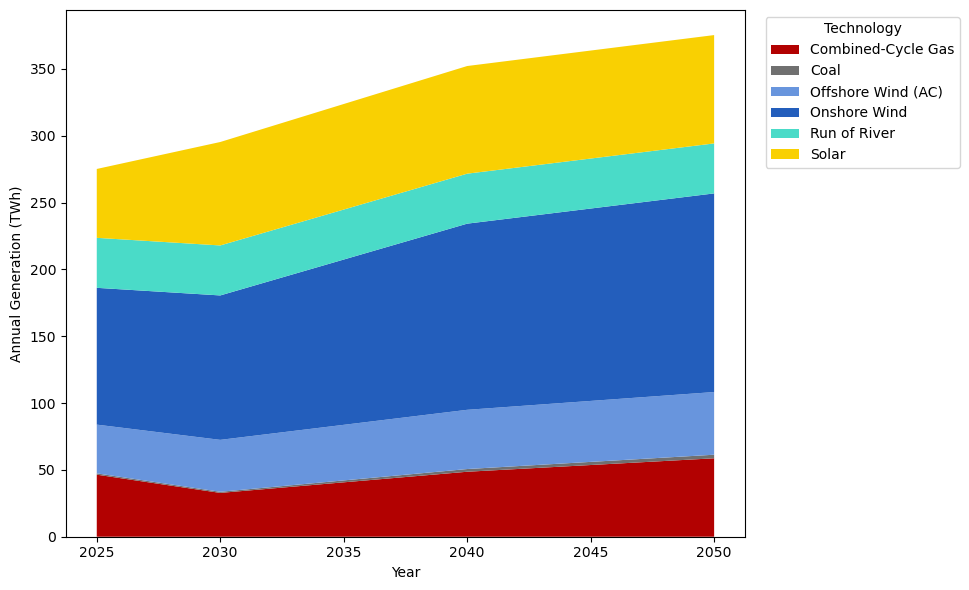

Evolution of Annual Energy Production by Technology (averaged across scenarios)


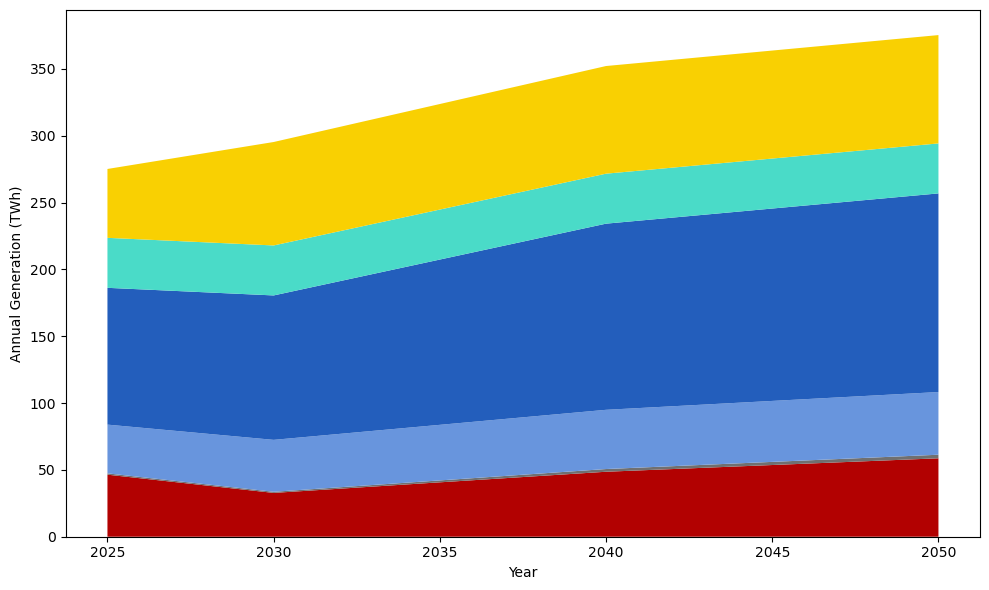

In [131]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


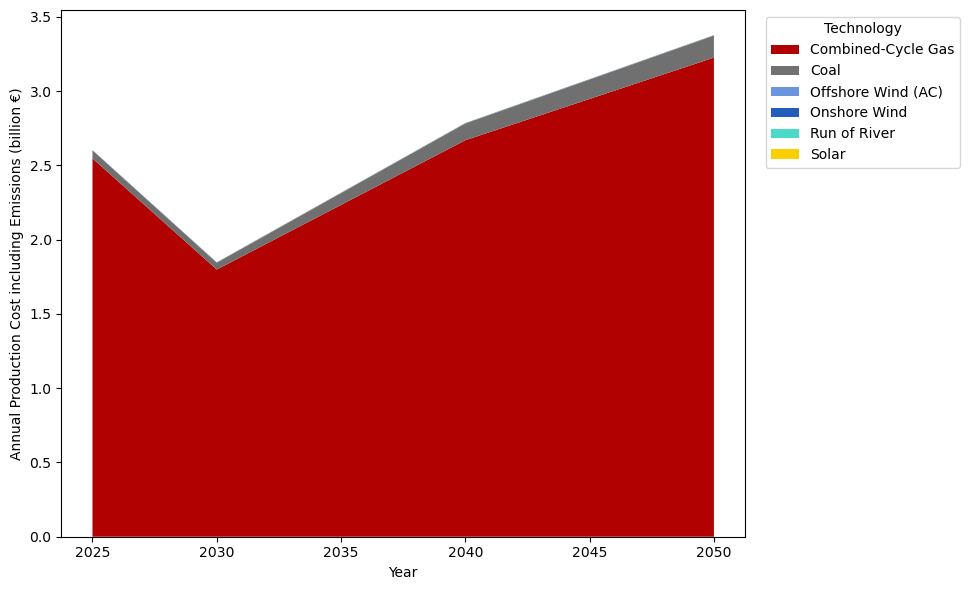

In [132]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [133]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.751310e+08  9.616088e+06       7.692871e+08     1.834843e+09   
2030 NT        2.953014e+08  6.839560e+06       5.471648e+08     1.300925e+09   
2040 DE        3.685813e+08  1.186147e+07       9.489179e+08     2.221985e+09   
     GA        3.279597e+08  8.329278e+06       6.663422e+08     1.567887e+09   
     NT        3.599054e+08  1.104651e+07       8.837204e+08     2.069268e+09   
2050 DE        3.977087e+08  1.486939e+07       1.189551e+09     2.781064e+09   
     GA        3.528882e+08  1.041756e+07       8.334051e+08     1.952074e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         2.604130e+09  
2030 NT                         1.848090e+09  
2040 DE                         3.170903e+09  
     GA                         2.234229e+09  
     NT                         2.952988e+09  
2050 DE                         3.970615e+09  
     GA                         2.785479e+09

CO₂ Emissions by Year and Scenario


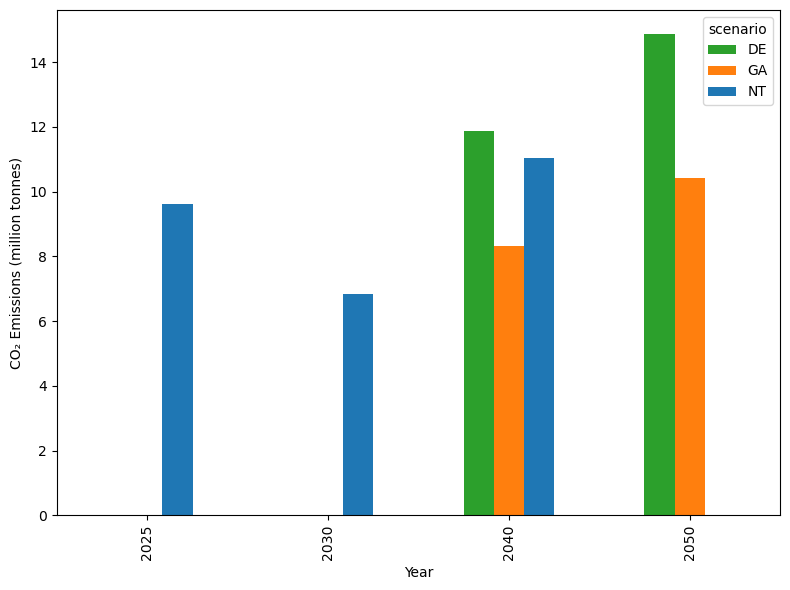

CO₂ Emissions by Year, Scenario, and Average


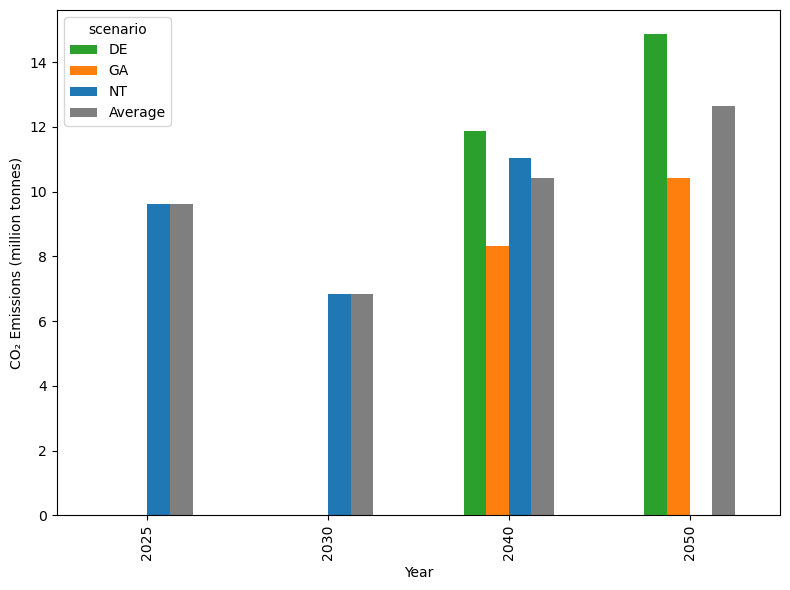

Annual Production by Year, Scenario, and Average


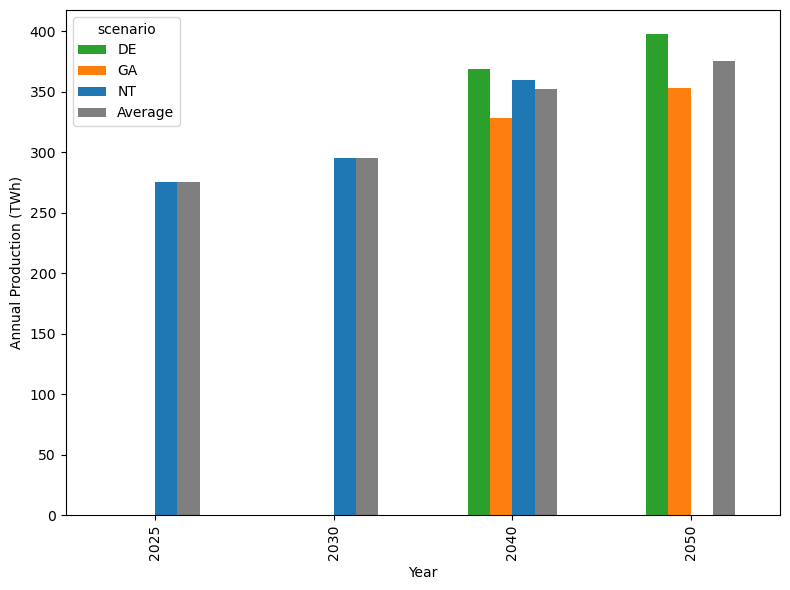

Production Cost by Year, Scenario, and Average


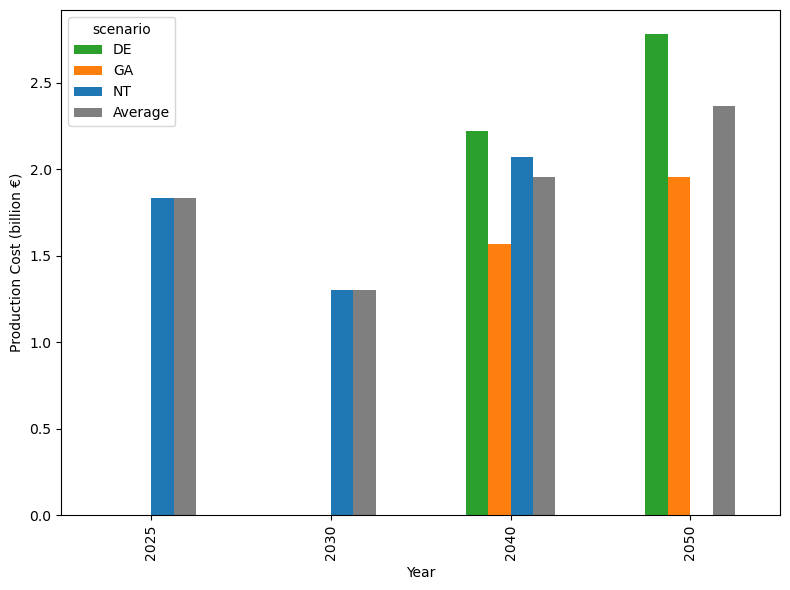

Production Cost w/ Emissions by Year, Scenario, and Average


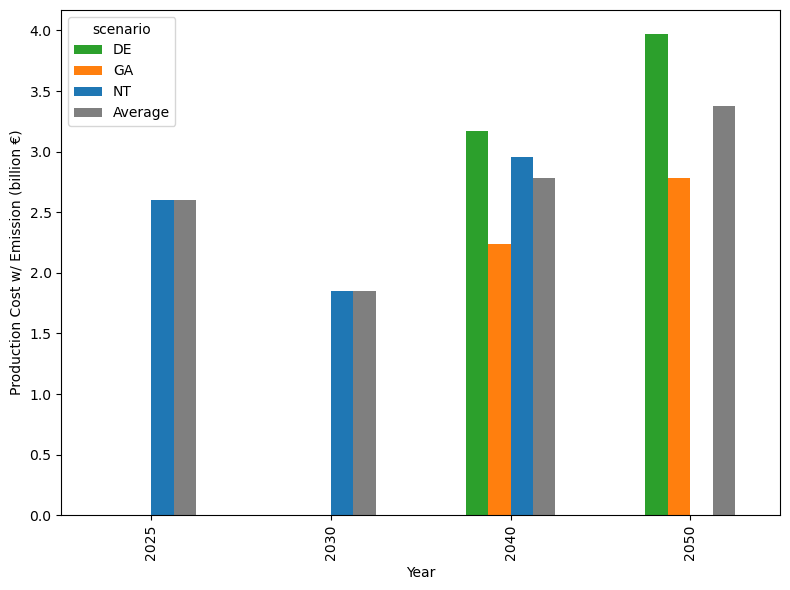

In [134]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [135]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [136]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [137]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,6850.600000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,13701.200000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,20551.800000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,27402.400000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,2137.049865,0.000000,0.000000,2137.049865,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299140.224929,0.00,#4adbc8,Run of River,True,539.200000,0.000000,539.200000,2156.800000,808.800000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,1296.147198,1296.147198,1944.220796
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,2592.294395,2592.294395,3240.367994


Annual Utilization Factor by Year, Scenario, and Carrier


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2481: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2482: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


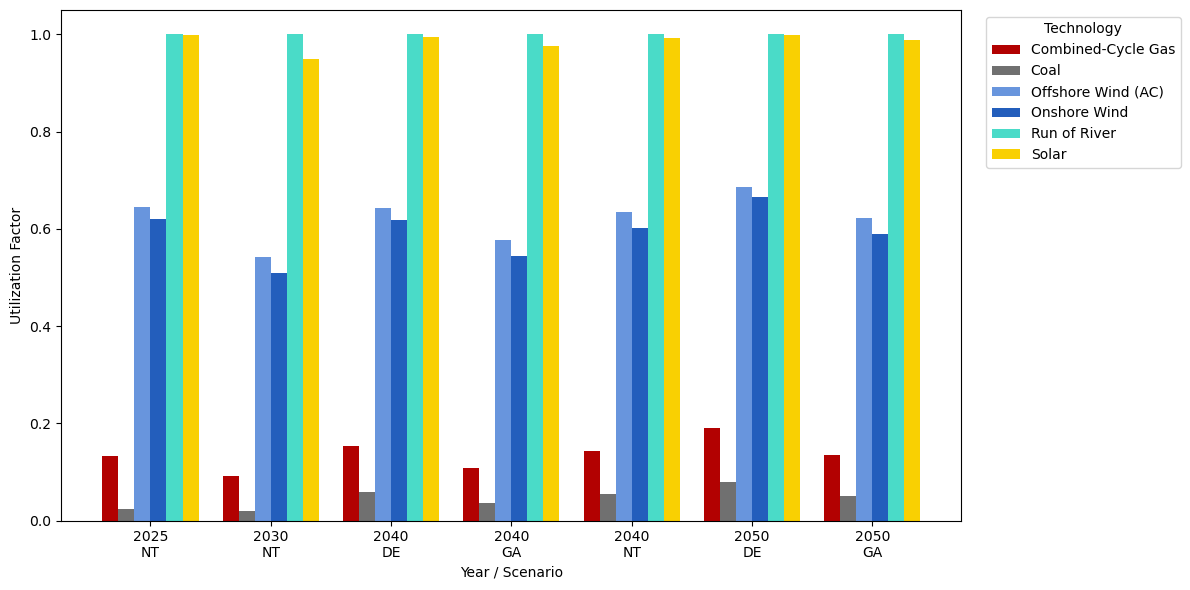

In [138]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [139]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [140]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,82048.185198,51,24,7.950137e+09,2.751310e+08,9.616088e+06,7.692871e+08,1.834843e+09,2.604130e+09,1.055427e+10
2030,192912.81714,42346.231012,51,13,3.099838e+09,2.953014e+08,6.839560e+06,5.471648e+08,1.300925e+09,1.848090e+09,4.947928e+09
2040,192912.81714,7666.034392,51,1,7.365977e+08,3.521488e+08,1.041242e+07,8.329935e+08,1.953047e+09,2.786040e+09,3.522638e+09
2050,192912.81714,0.000000,51,0,0.000000e+00,3.752985e+08,1.264348e+07,1.011478e+09,2.366569e+09,3.378047e+09,3.378047e+09


In [141]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              60900.664000   9540.887314                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   5750.206760                          9   
     onwind            64079.006689  36066.052577                         11   
     ror                5571.016495   5277.000000                          4   
     solar             25414.038546  25414.038546                         11   
2030 CCGT              60900.664000   1310.468366                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   3638.183698                          9   
     onwind            64079.006689  16021.999255                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546  21375.579694                         11   
2040 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689   7666.034392                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546      0.000000                         11   
2050 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689      0.000000                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546      0.000000                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              3      9.448124e+08      4.642504e+07   
     coal                              0      0.000000e+00      9.737656e+05   
     offwind-ac                        2      1.056531e+09      3.646754e+07   
     onwind                            6      3.465439e+09      1.023460e+08   
     ror                               2      1.578563e+09      3.739784e+07   
     solar                            11      9.047924e+08      5.152083e+07   
2030 CCGT                              2      1.297727e+08      3.278349e+07   
     coal                              0      0.000000e+00      8.319495e+05   
     offwind-ac                        1      6.695623e+08      3.885367e+07   
     onwind                            2      1.539488e+09      1.080506e+08   
     ror                               0      0.000000e+00      3.739784e+07   
     solar                             8      7.610149e+08      7.738377e+07   
2040 CCGT                              0      0.000000e+00      4.861161e+07   
     coal                              0      0.000000e+00      2.029698e+06   
     offwind-ac                        0      0.000000e+00      4.430422e+07   
     onwind                            1      7.365977e+08      1.392734e+08   
     ror                               0      0.000000e+00      3.739784e+07   
     solar                             0      0.000000e+00      8.053204e+07   
2050 CCGT                              0      0.000000e+00      5.867804e+07   
     coal                              0      0.000000e+00      2.670204e+06   
     offwind-ac                        0      0.000000e+00      4.689541e+07   
     onwind                            0      0.000000e+00      1.486063e+08   
     ror        

## Transmission Lines

In [142]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [143]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [144]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [145]:
branches["capital_cost"]

year  line
2025  88      23102.962586
2030  88      23102.962586
2040  88      23102.962586
2050  88      23102.962586
2025  89      11729.199350
                  ...     
2050  107     22061.025373
2025  219     14480.882016
2030  219     14480.882016
2040  219     14480.882016
2050  219     14480.882016
Name: capital_cost, Length: 76, dtype: float64

Annual New Branch Capacity Additions


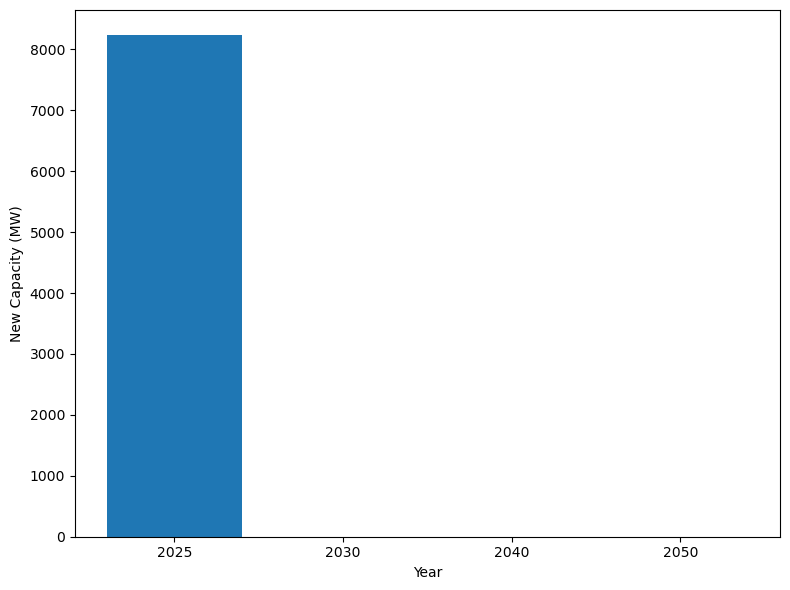

In [146]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [147]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,8234.121856,19,2,1.403753e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [148]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.994905         0.967262
              2050          0.993681         0.959821
     GA       2040          0.995690         0.976190
              2050          0.995085         0.971726
     NT       2025          0.998403         0.991071
...                              ...              ...
219  GA       2040          0.627942         0.166667
              2050          0.648317         0.190476
     NT       2025          0.675827         0.205357
              2030          0.615578         0.133929
              2040          0.654073         0.194940

[133 rows x 2 columns]

In [149]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.628759         0.512923
2030 NT                0.632525         0.512375
2040 DE                0.647320         0.518327
     GA                0.639527         0.514411
     NT                0.645708         0.515742
2050 DE                0.652498         0.519032
     GA                0.644331         0.516839

Transmission line investments in 2025:


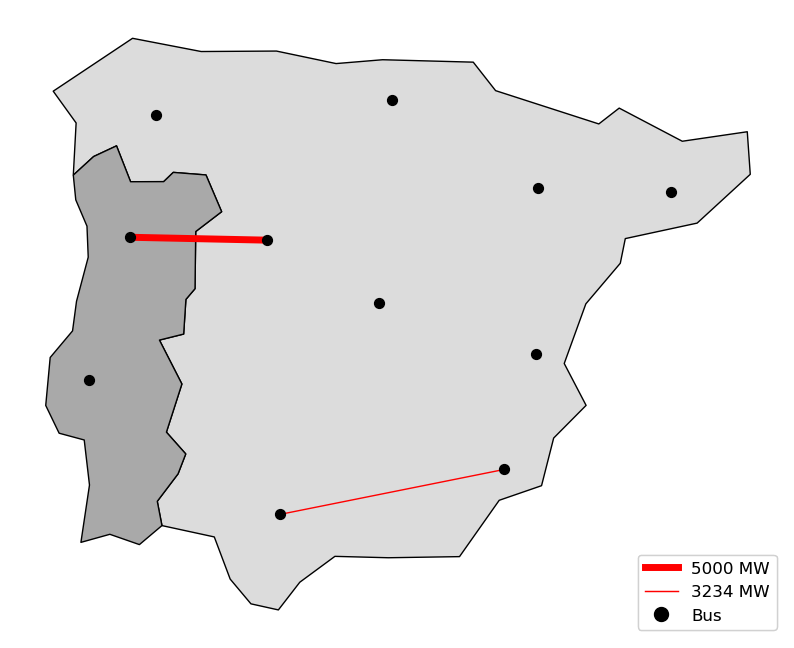

Plotting grid with new branches in year 2025


In [150]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [151]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

In [152]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

In [153]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,2,270.831963,5.947179e+06,237.895019
2030,2,761.534279,1.077530e+07,190.794819
2040,2,7751.058566,1.534824e+08,244.843431
2050,2,34522.876131,5.878803e+08,183.046689


Annual Curtailment by Year and Scenario


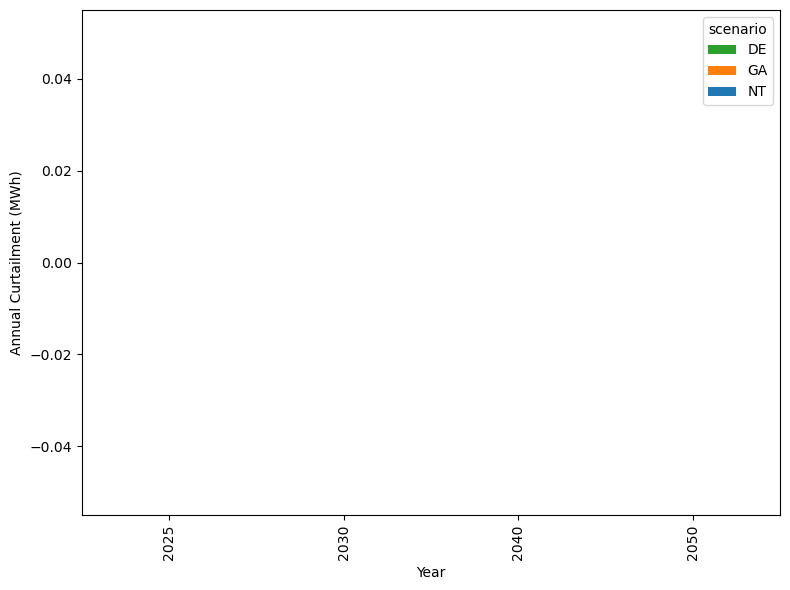

Annual Load Shedding by Year and Scenario


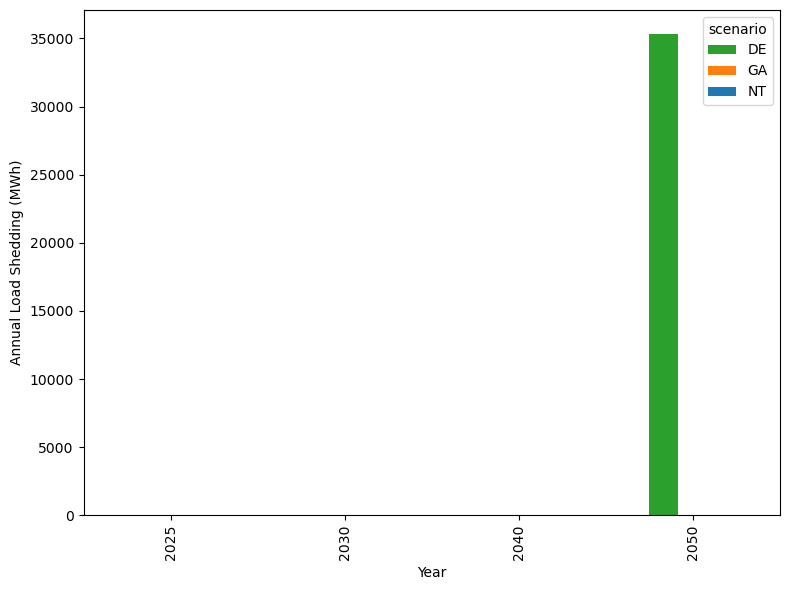

In [154]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [155]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT             0.000000          0.0        0.000000e+00   
2030 NT             0.000000          0.0        0.000000e+00   
2040 DE             0.000000          0.0        0.000000e+00   
     GA             0.000000          0.0        0.000000e+00   
     NT             0.000000          0.0        0.000000e+00   
2050 DE         35323.135379          0.0        2.243019e+08   
     GA             0.000000          0.0        0.000000e+00   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [156]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [157]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [158]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,82048.185198,51,24,7.950137e+09,2.751310e+08,9.616088e+06,7.692871e+08,1.834843e+09,2.604130e+09,1.055427e+10
2030,192912.81714,42346.231012,51,13,3.099838e+09,2.953014e+08,6.839560e+06,5.471648e+08,1.300925e+09,1.848090e+09,4.947928e+09
2040,192912.81714,7666.034392,51,1,7.365977e+08,3.521488e+08,1.041242e+07,8.329935e+08,1.953047e+09,2.786040e+09,3.522638e+09
2050,192912.81714,0.000000,51,0,0.000000e+00,3.752985e+08,1.264348e+07,1.011478e+09,2.366569e+09,3.378047e+09,3.378047e+09


In [159]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [160]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,NaN,NaN,NaN,NaN
2030,NaN,NaN,NaN,NaN
2040,NaN,NaN,NaN,NaN
2050,NaN,NaN,NaN,NaN


In [161]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [162]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,8234.121856,19,2,1.403753e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [163]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.751310e+08  9.616088e+06       7.692871e+08     1.834843e+09   
2030 NT        2.953014e+08  6.839560e+06       5.471648e+08     1.300925e+09   
2040 DE        3.685813e+08  1.186147e+07       9.489179e+08     2.221985e+09   
     GA        3.279597e+08  8.329278e+06       6.663422e+08     1.567887e+09   
     NT        3.599054e+08  1.104651e+07       8.837204e+08     2.069268e+09   
2050 DE        3.977087e+08  1.486939e+07       1.189551e+09     2.781064e+09   
     GA        3.528882e+08  1.041756e+07       8.334051e+08     1.952074e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         2.604130e+09  
2030 NT                         1.848090e+09  
2040 DE                         3.170903e+09  
     GA                         2.234229e+09  
     NT                         2.952988e+09  
2050 DE                         3.970615e+09  
     GA                         2.785479e+09

In [164]:
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT             0.000000          0.0        0.000000e+00   
2030 NT             0.000000          0.0        0.000000e+00   
2040 DE             0.000000          0.0        0.000000e+00   
     GA             0.000000          0.0        0.000000e+00   
     NT             0.000000          0.0        0.000000e+00   
2050 DE         35323.135379          0.0        2.243019e+08   
     GA             0.000000          0.0        0.000000e+00   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

Annual System Costs (average across scenarios)


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:3506: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)


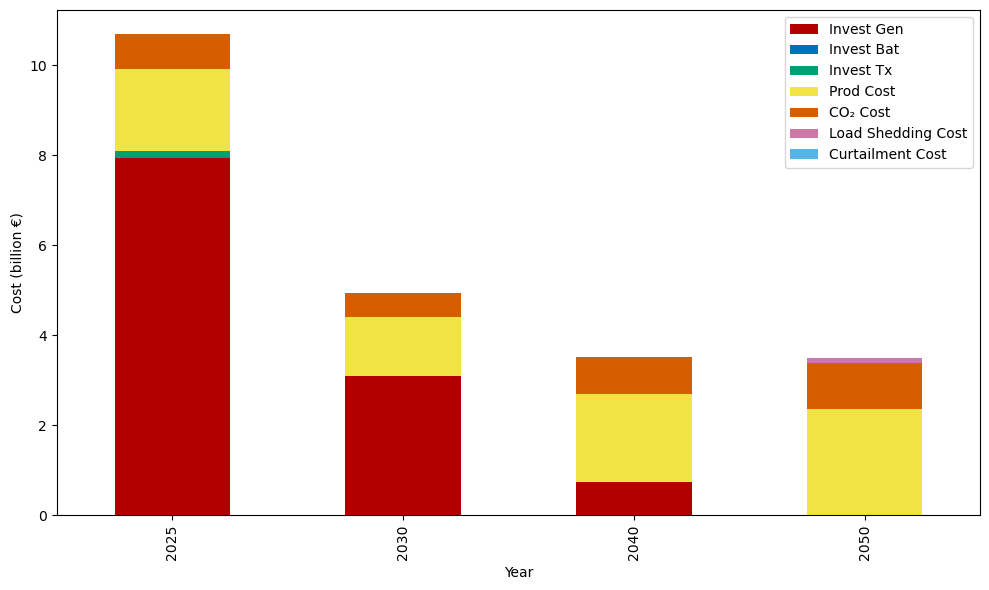

Annual System Costs by Scenario


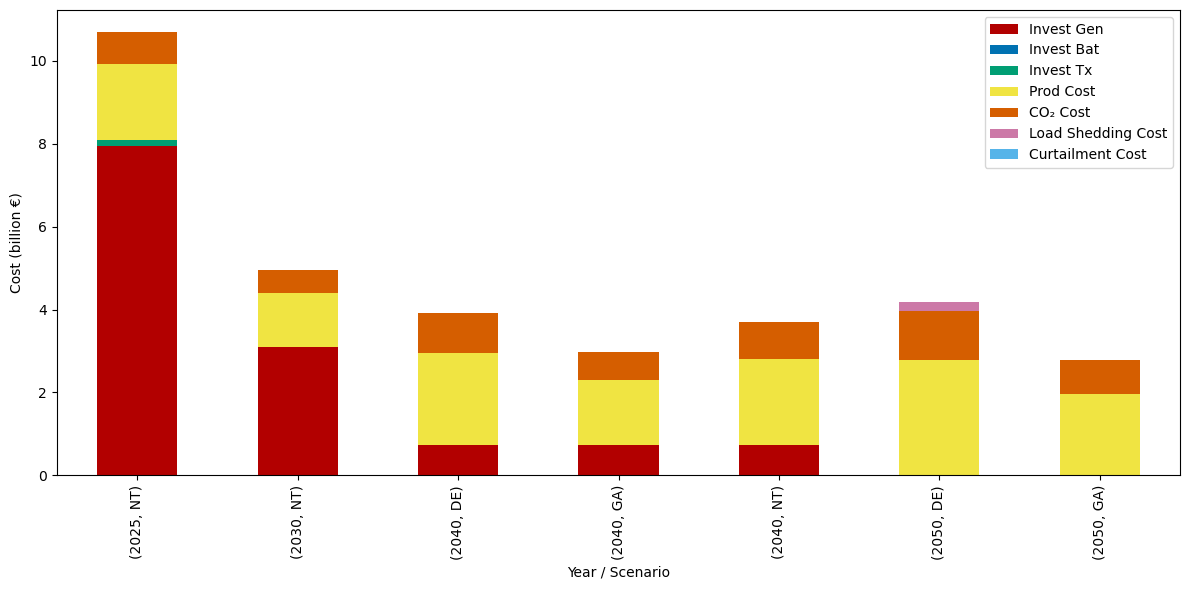

In [165]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [166]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:3618: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  battery_investment = battery_summary["investment_cost"].fillna(0)


,AIC,expected_OC,total_cost
year,,,
2025,8.090513e+09,2.604130e+09,1.069464e+10
2030,3.099838e+09,1.848090e+09,4.947928e+09
2040,7.365977e+08,2.786040e+09,3.522638e+09
2050,0.000000e+00,3.490198e+09,3.490198e+09


In [167]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [168]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen  Invest Bat     Invest Tx  Production Cost  \
year scenario                                                            
2025 NT        7.950137e+09         NaN  1.403753e+08     1.834843e+09   
2030 NT        3.099838e+09         NaN  0.000000e+00     1.300925e+09   
2040 DE        7.365977e+08         NaN  0.000000e+00     2.221985e+09   
     GA        7.365977e+08         NaN  0.000000e+00     1.567887e+09   
     NT        7.365977e+08         NaN  0.000000e+00     2.069268e+09   
2050 DE        0.000000e+00         NaN  0.000000e+00     2.781064e+09   
     GA        0.000000e+00         NaN  0.000000e+00     1.952074e+09   
All  All       1.178657e+10         0.0  1.403753e+08     7.455383e+09   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             7.692871e+08        0.000000e+00               0.0   
2030 NT             5.471648e+08        0.000000e+00               0.0   
2040 DE             9.489179e+08        0.000000e+00               0.0   
     GA             6.663422e+08        0.000000e+00               0.0   
     NT             8.837204e+08        0.000000e+00               0.0   
2050 DE             1.189551e+09        2.243019e+08               0.0   
     GA             8.334051e+08        0.000000e+00               0.0   
All  All            3.160924e+09        1.121510e+08               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         2.604130e+09  8.090513e+09  2.604130e+09  1.069464e+10  
2030 NT         1.848090e+09  3.099838e+09  1.848090e+09  4.947928e+09  
2040 DE         3.170903e+09  7.365977e+08  3.170903e+09  3.907501e+09  
     GA         2.234229e+09  7.365977e+08  2.234229e+09  2.970827e+09  
     NT         2.952988e+09  7.365977e+08  2.952988e+09  3.689586e+09  
2050 DE         3.970615e+09  0.000000e+00  4.194917e+09  4.194917e+09  
     GA         2.785479e+09  0.000000e+00  2.785479e+09  2.785479e+09  
All  All        1.061631e+10  1.192695e+10  1.072846e+10  2.265541e+10

In [169]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,6850.600000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,13701.200000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,20551.800000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,6850.600000,0.000000,0.000000,27402.400000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,2137.049865,0.000000,0.000000,2137.049865,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299140.224929,0.00,#4adbc8,Run of River,True,539.200000,0.000000,539.200000,2156.800000,808.800000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,1296.147198,1296.147198,1944.220796
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,1296.147198,1296.147198,2592.294395,2592.294395,3240.367994


In [170]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [171]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



,,,,,dual_value
battery,scenario,year,week,hour,


------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0        0.01505
                         1        0.01500

------------------------


In [172]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [173]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



,,,,,dual_value
battery,scenario,year,week,hour,


,,,,,dual_value,p,weight
battery,scenario,year,week,hour,,,


battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0        0.01505
                         1        0.01500

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0        0.01505  1.0     1.0
                         1        0.01500  1.0     1.0

In [174]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [175]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [176]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [177]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        27.734384  27.350291  27.684078  27.442182  27.665834   
2030 NT        20.003893  19.742309  19.977114  19.807058  19.968502   
2040 DE        26.195452  25.905117  26.207540  25.985129  26.025011   
     GA        20.760889  20.512754  20.755918  20.576259  20.581021   
     NT        24.683339  24.407313  24.694009  24.480962  24.510002   
2050 DE        50.217939  49.998400  50.592606  50.249547  50.322375   
     GA        24.030502  23.753868  24.034044  23.825454  23.851417   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        27.741553  28.022342  28.002226  27.948380  27.781962   
2030 NT        20.023136  20.221209  20.211283  20.167837  20.082868   
2040 DE        26.269116  26.527763  26.515437  26.457745  26.337978   
     GA        20.801751  21.009529  20.996182  20.954077  20.861712   
     NT        24.749052  24.995739  24.980573  24.929765  24.808690   
2050 DE        50.797727  51.210784  51.275048  51.075618  50.900678   
     GA        24.086904  24.327710  24.311687  24.263499  24.145816   

node               PT1 1  
year scenario             
2025 NT        28.041121  
2030 NT        20.254521  
2040 DE        26.561827  
     GA        21.036441  
     NT        25.018434  
2050 DE        51.348412  
     GA        24.350378

In [178]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

Average LMP across years: 27.29 €/MWh


scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,27.764941,27.764941
2030,NaN,NaN,20.041794,20.041794
2040,26.271647,20.804230,24.750716,23.942198
2050,50.726285,24.089207,NaN,37.407746


Average LMP by Year and Scenario (±1 std)


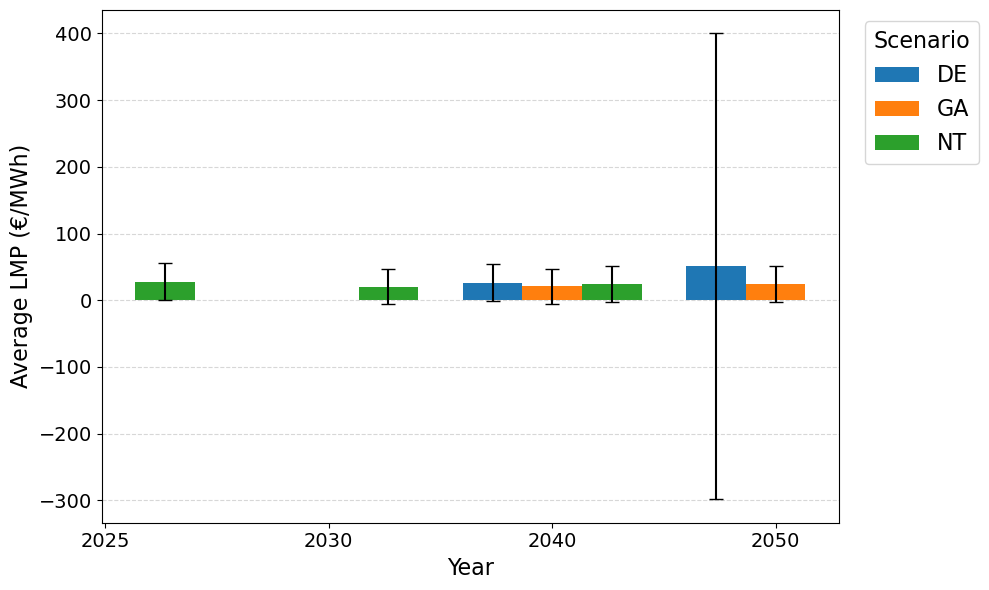

In [179]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


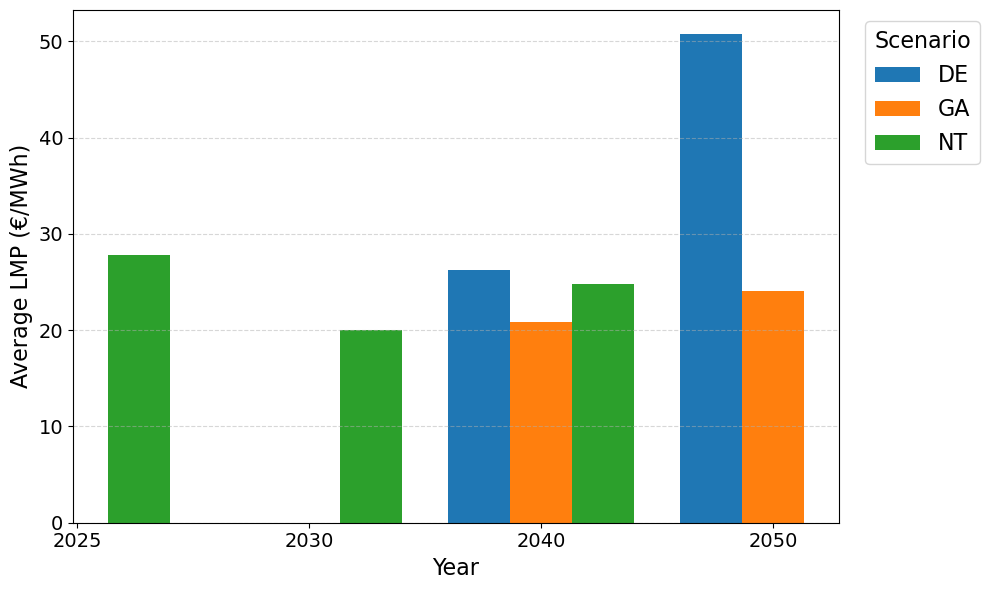

In [180]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


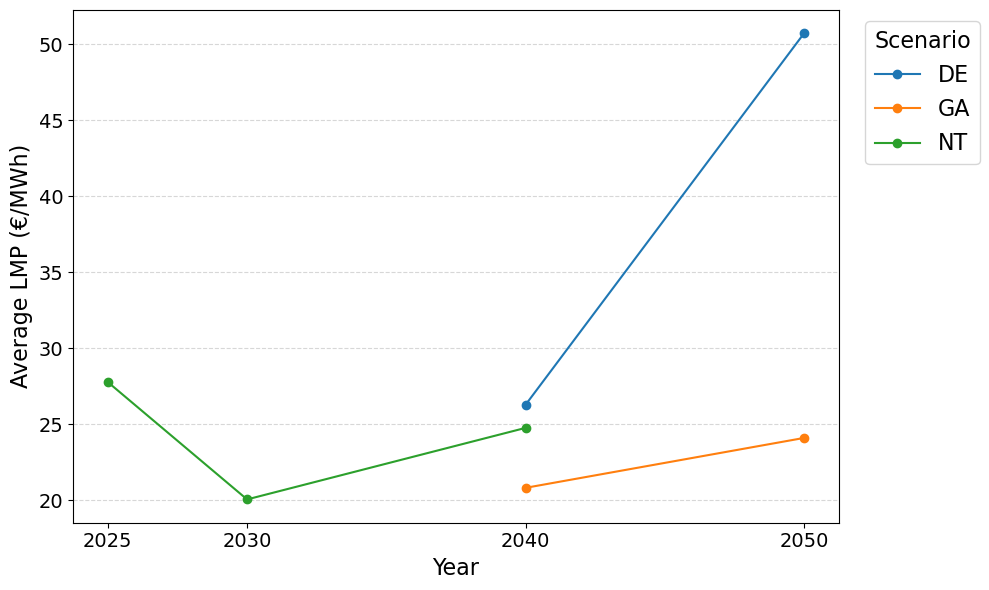

In [181]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


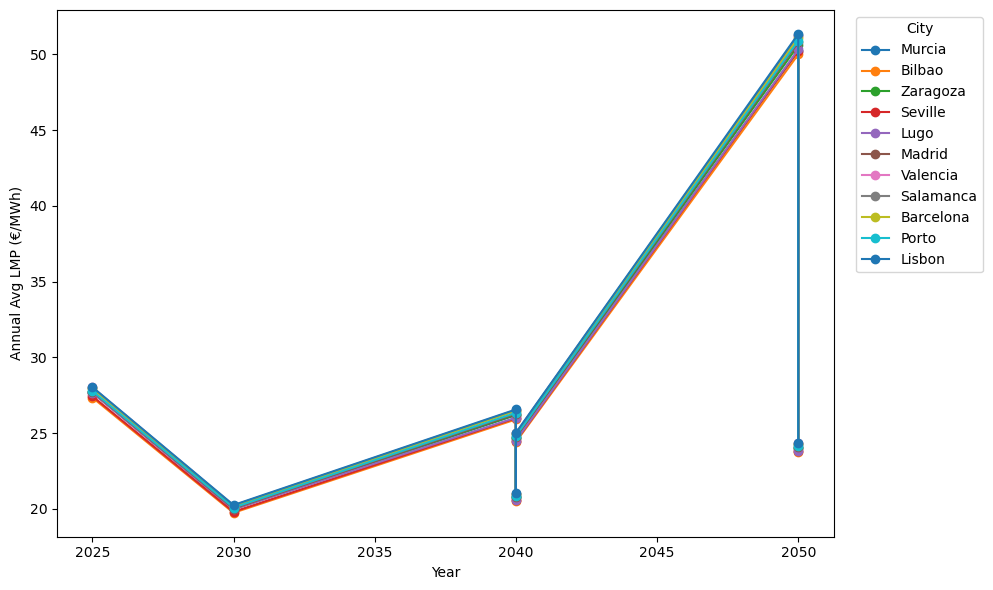

In [182]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


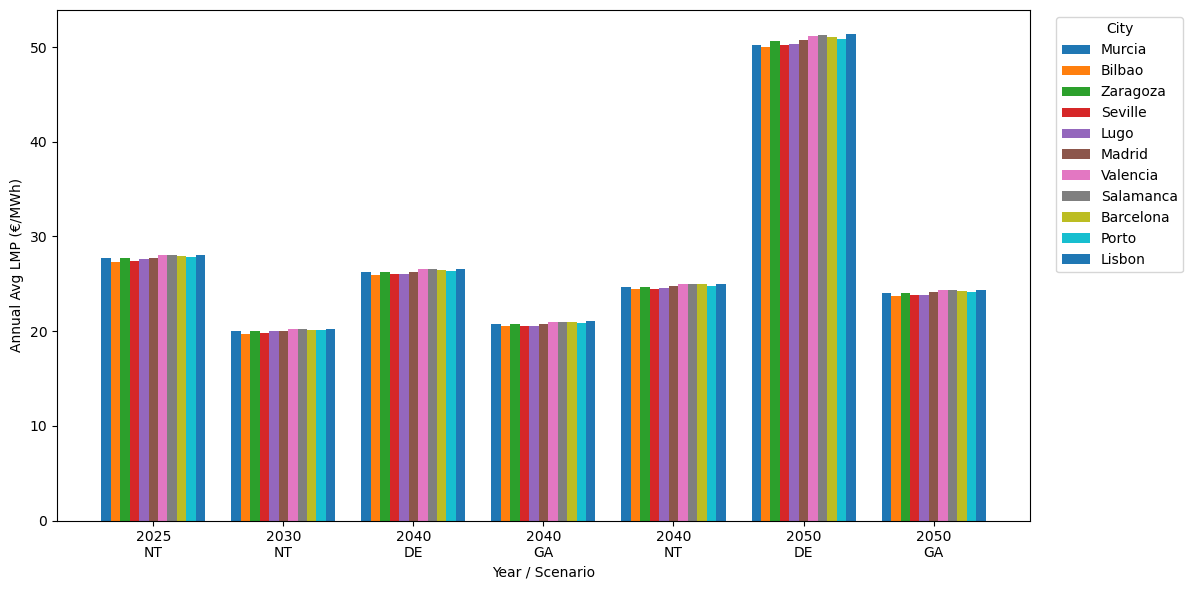

In [183]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [184]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year            
88   2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0
89   2025         0.0
...               ...
107  2050         0.0
219  2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0

[76 rows x 1 columns]

In [185]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [186]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,1562,3.018707
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,26797,51.787647
gap_wind_thermal,0.016500,49.857273,0,0.000000
thermal,49.857273,62.172437,23220,44.874768
other,NaN,NaN,165,0.318878


LMP Bucket Absolute Frequencies


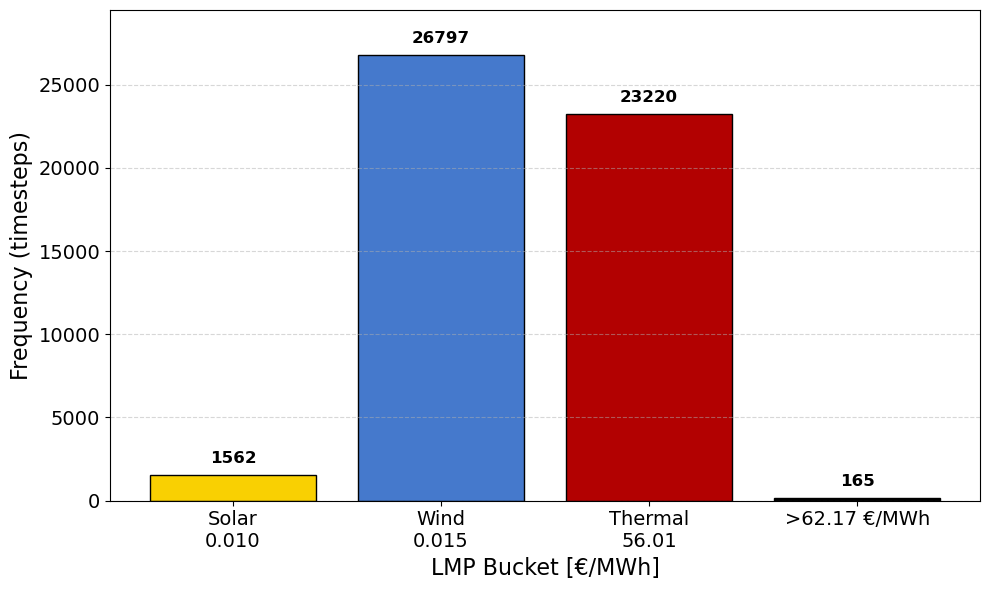

In [187]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [188]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,1562,3.018707
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,26797,51.787647
gap_wind_thermal,0.016500,49.857273,0,0.000000
thermal,49.857273,62.172437,23220,44.874768
other,NaN,NaN,165,0.318878


LMP Bucket Relative Frequencies (%)


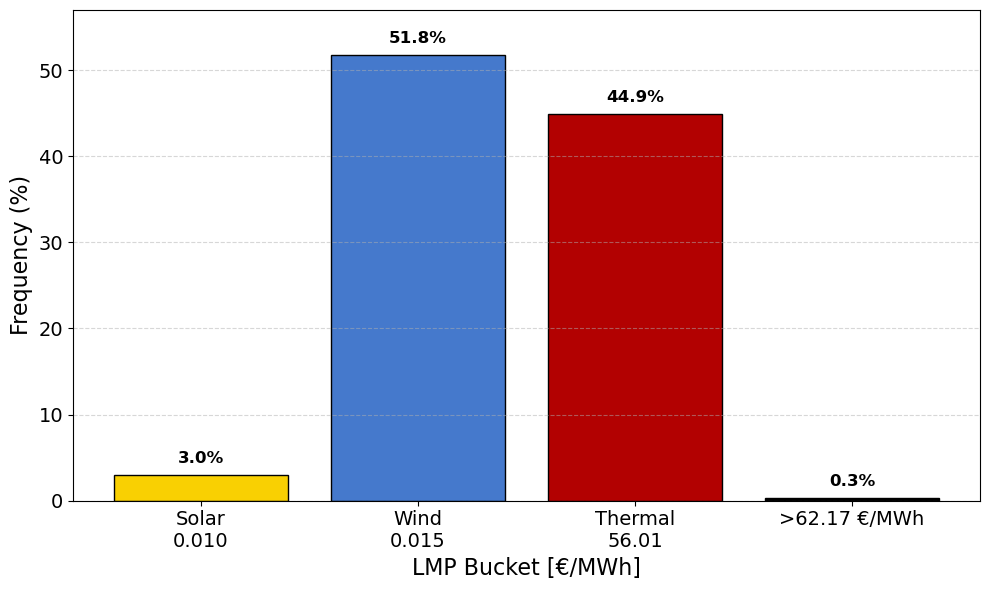

In [189]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

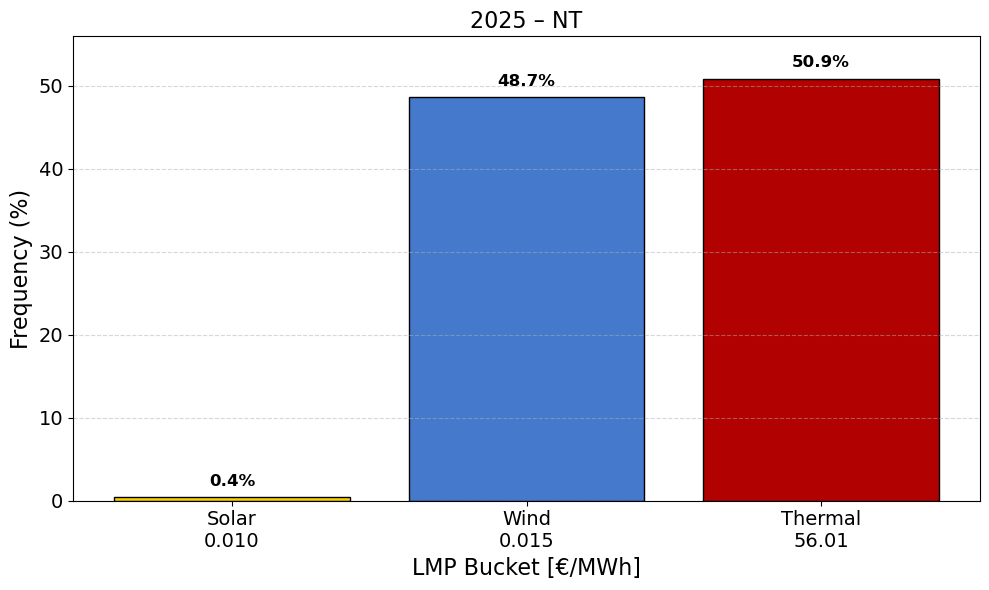

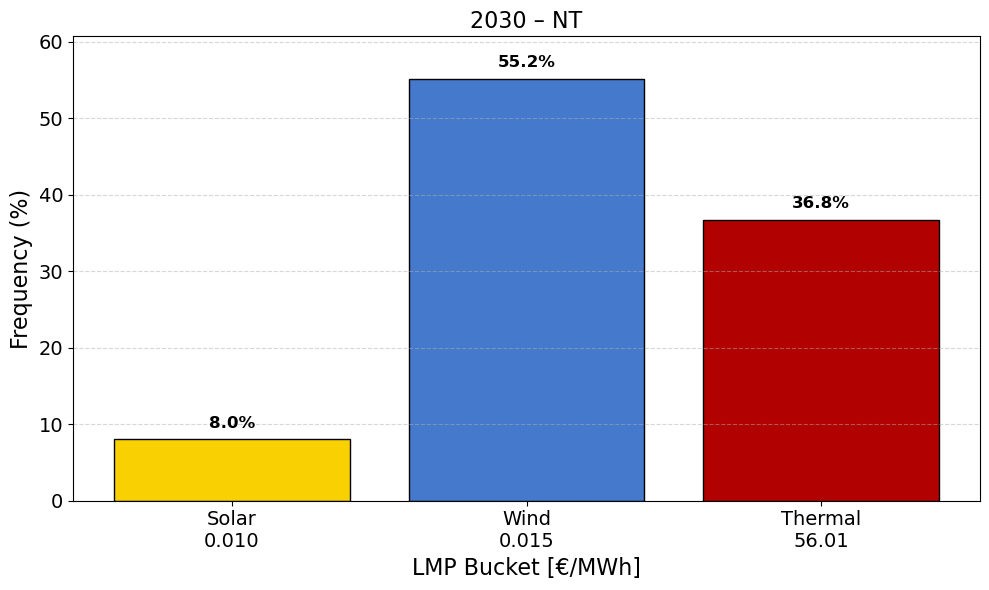

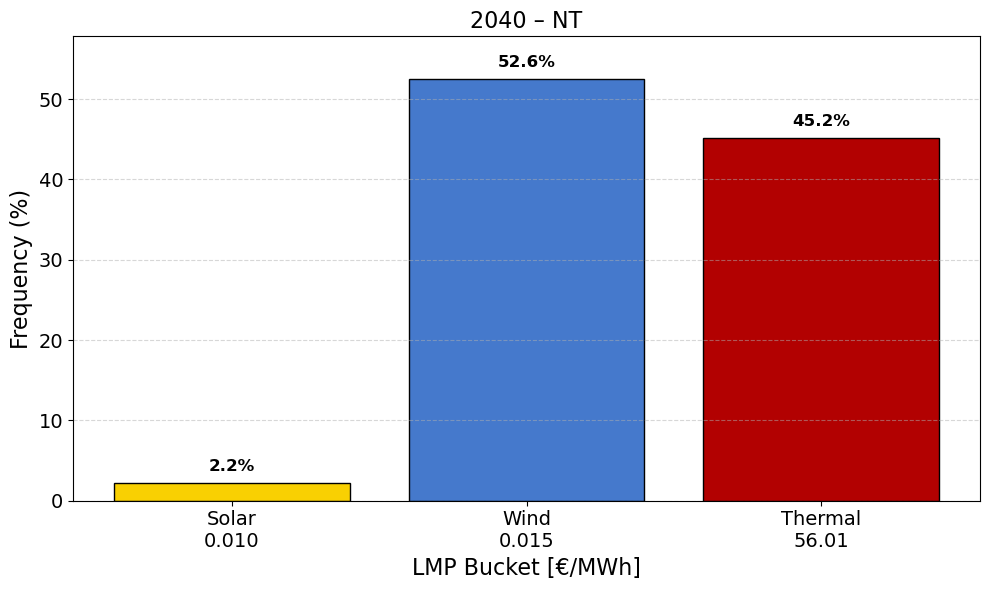

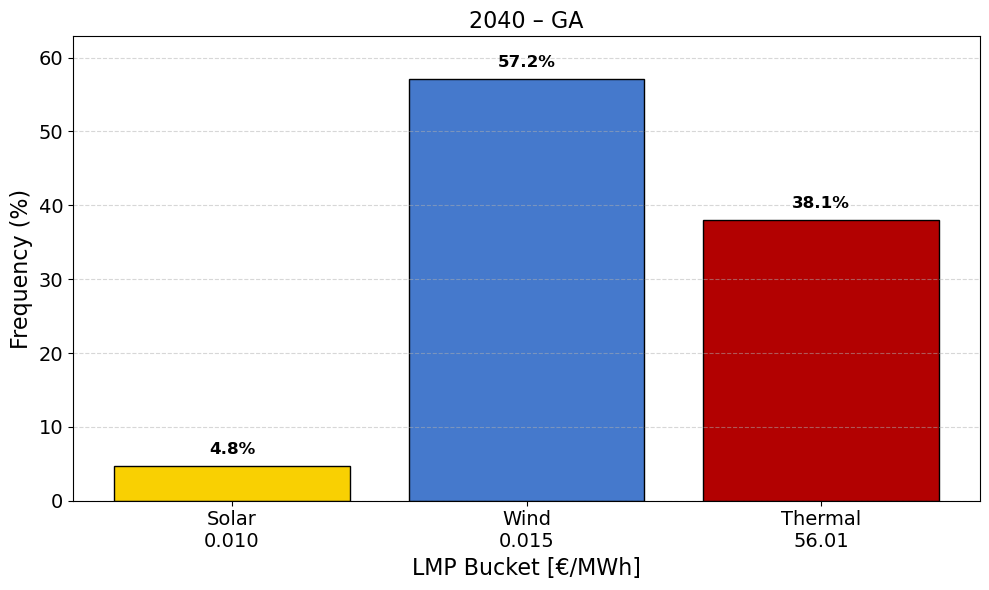

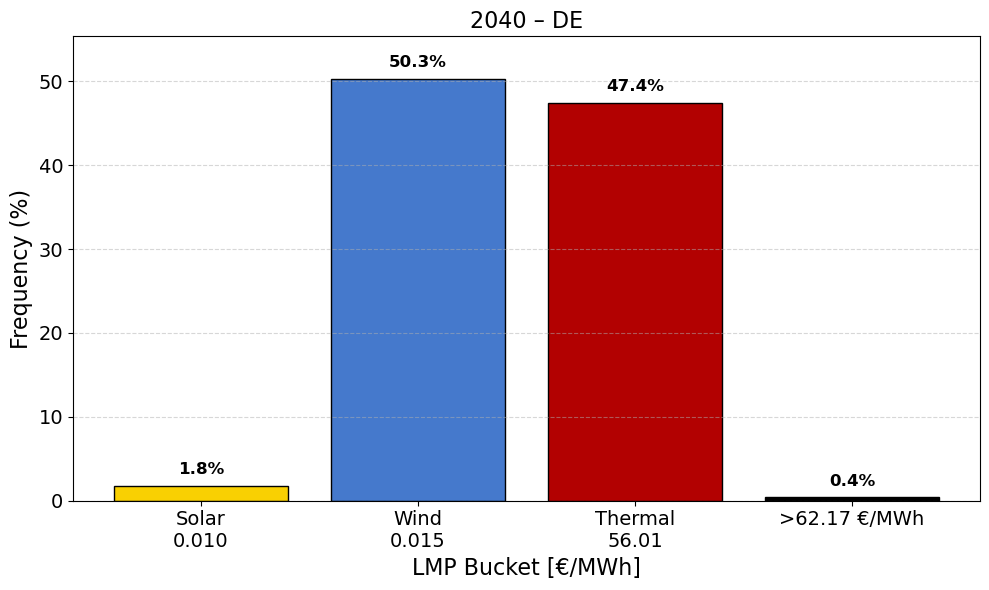

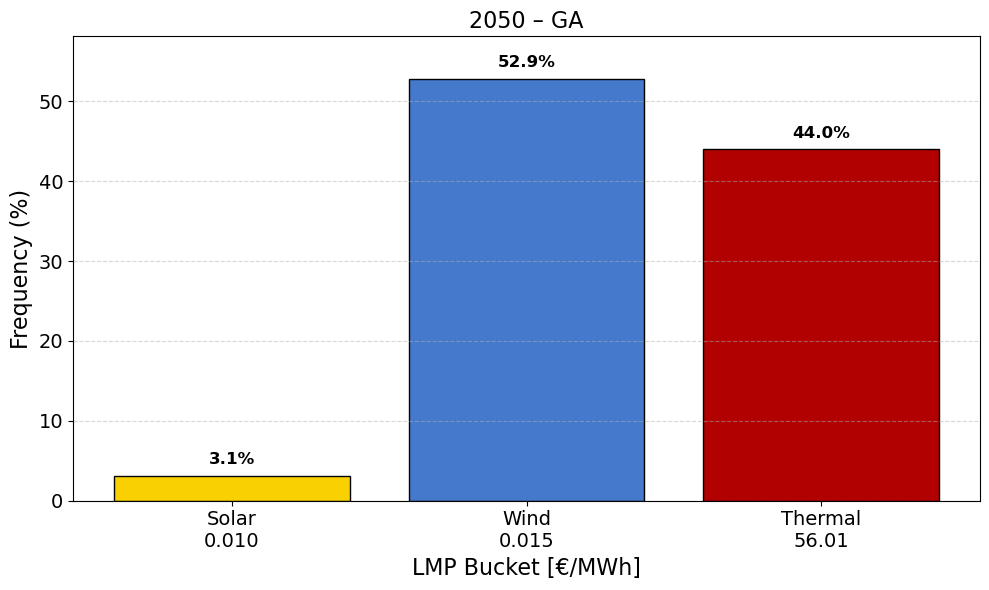

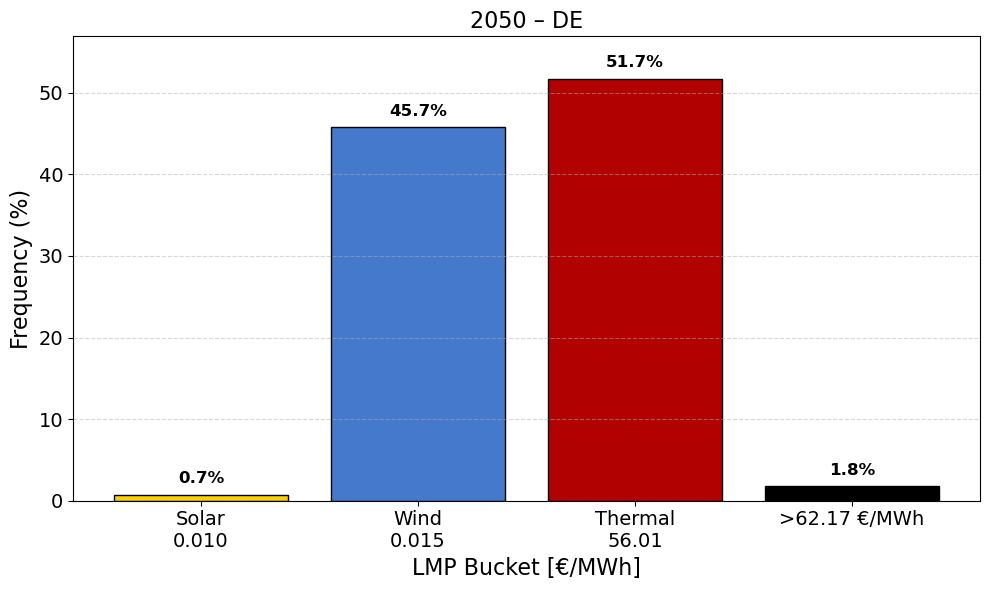

In [190]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

LMP event counts above 62.17 €/MWh by Year & Scenario


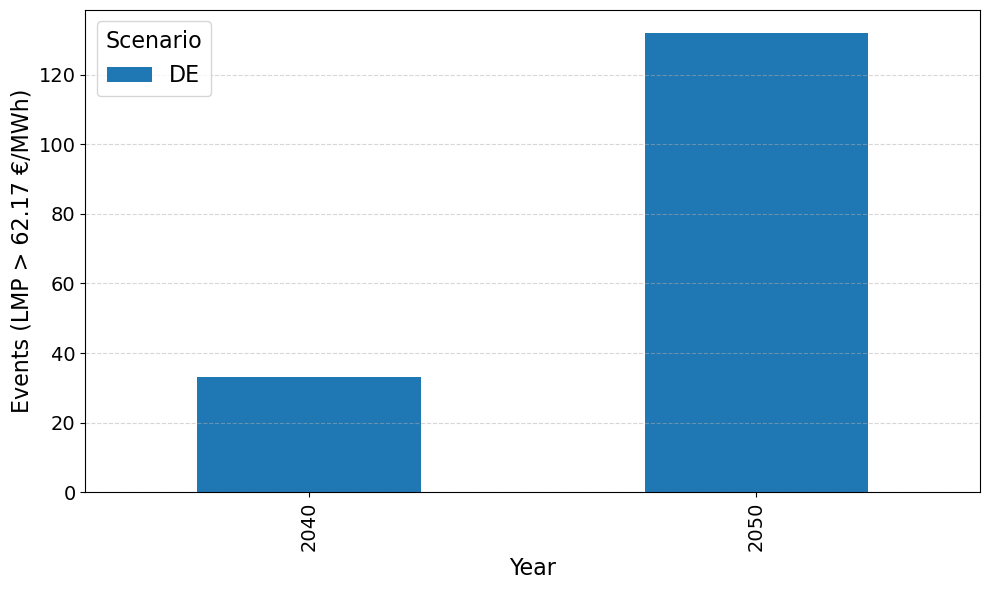

In [191]:
# determine cap from your buckets:
cap = freqs.loc[freqs.index != "other", "upper"].max()

analytics.plot_high_lmp_event_counts(power_balance_duals, cap, savefolder=dual_folder)

62.1724371519848
Distribution of LMPs > 62.17 €/MWh


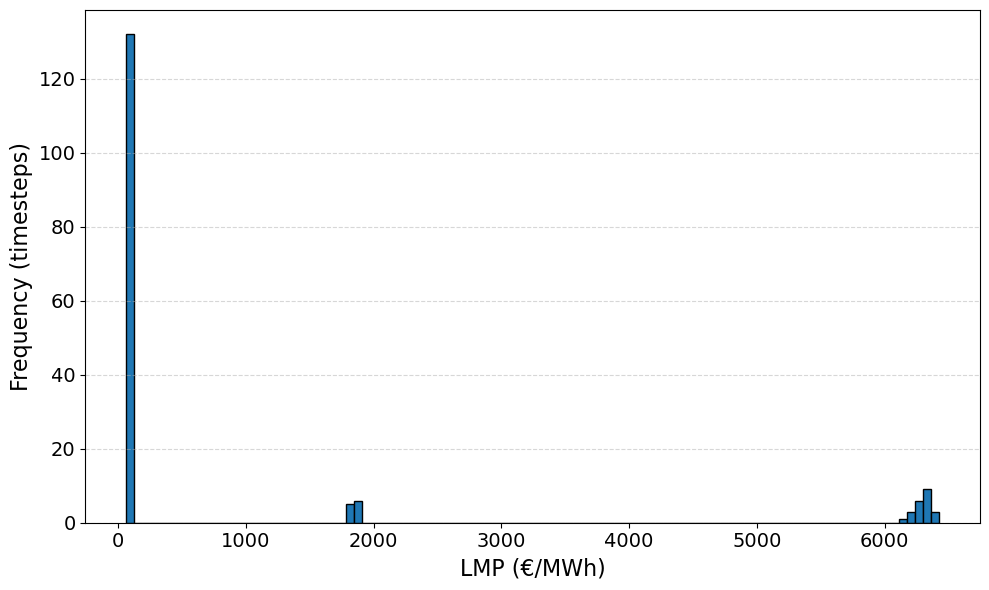

In [192]:
cap = freqs.loc[freqs.index != "other", "upper"].max()
print(cap)


analytics.plot_high_lmp_distribution(
    power_balance_duals, cap, n_bins=100, savefolder=dual_folder
)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
48     6191.725     6310.303     11        33.333333          0.021259
49     6310.303     6428.880     10        30.303030          0.019326
11     1804.354     1922.931     10        30.303030          0.019326
47     6073.148     6191.725      1         3.030303          0.001933
10     1685.776     1804.354      1         3.030303          0.001933
37     4887.372     5005.949      0         0.000000          0.000000
28     3820.173     3938.751      0         0.000000          0.000000
29     3938.751     4057.328      0         0.000000          0.000000
30     4057.328     4175.906      0         0.000000          0.000000
31     4175.906     4294.484      0         0.000000          0.000000
Top 5 high-LMP bins by occurrence


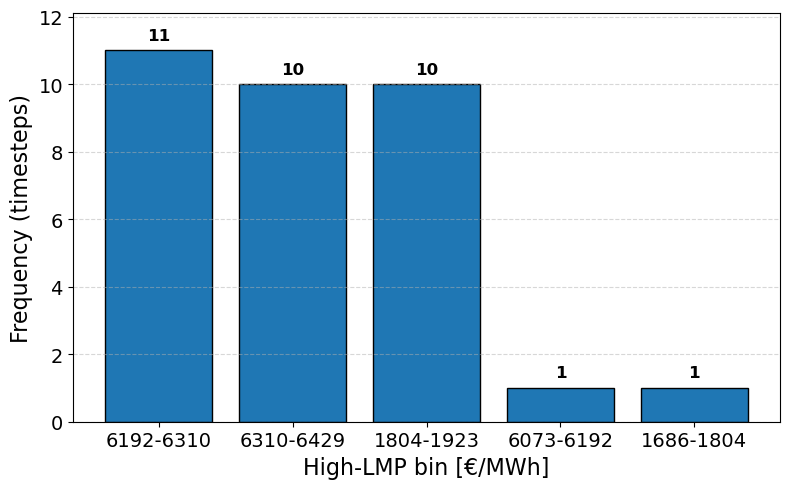

In [193]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        62.171      125.840    132        80.000000          0.255102
98     6301.546     6365.213      9         5.454545          0.017393
97     6237.879     6301.546      6         3.636364          0.011596
28     1844.851     1908.518      6         3.636364          0.011596
27     1781.184     1844.851      5         3.030303          0.009663
96     6174.212     6237.879      3         1.818182          0.005798
99     6365.213     6428.880      3         1.818182          0.005798
95     6110.545     6174.212      1         0.606061          0.001933
7       507.842      571.509      0         0.000000          0.000000
65     4200.533     4264.200      0         0.000000          0.000000
Top 6 high-LMP bins by occurrence


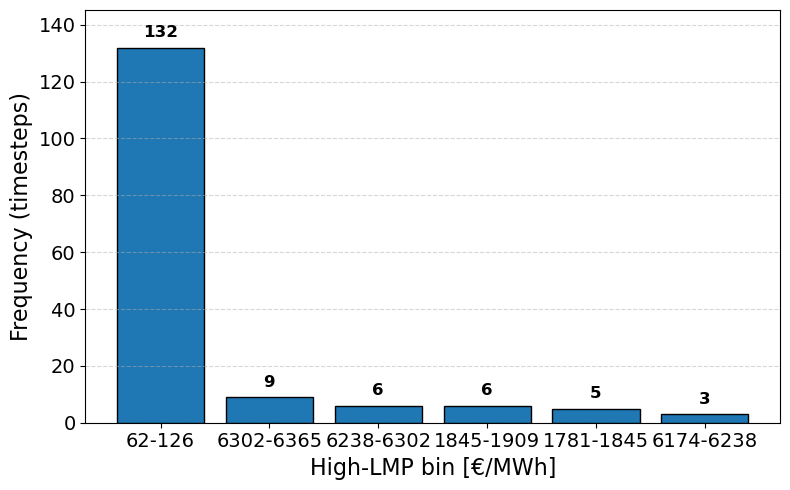

In [194]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (62.17–125.84 €/MWh)


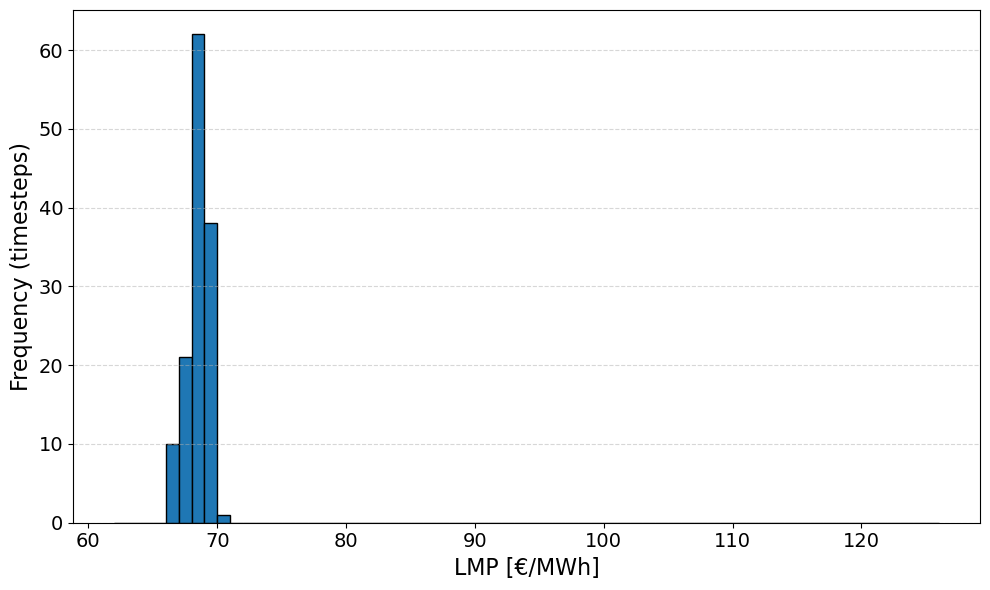

In [195]:
# Assuming you've already built `high_tbl`:
analytics.plot_top_high_bucket_detail(
    power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
)

In [196]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.015050  1.0     1.0
                         1       0.015000  1.0     1.0
                         2       0.014951  1.0     1.0
                         3       0.014909  1.0     1.0
                         4       0.014909  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 52   163    54.892841  0.5     2.0
                         164    54.892841  0.5     2.0
                         165    54.892841  0.5     2.0
                         166    54.892841  0.5     2.0
                         167    54.892841  0.5     2.0

[51744 rows x 3 columns]

In [197]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT               7392             0                      0.0
2030 NT               7392             0                      0.0
2040 DE               7392             0                      0.0
     GA               7392             0                      0.0
     NT               7392             0                      0.0
2050 DE               7392             0                      0.0
     GA               7392             0                      0.0
No duals found in bucket 'gap_wind_thermal'.


LMP ≥ 70 €/MWh: count = 34 timesteps


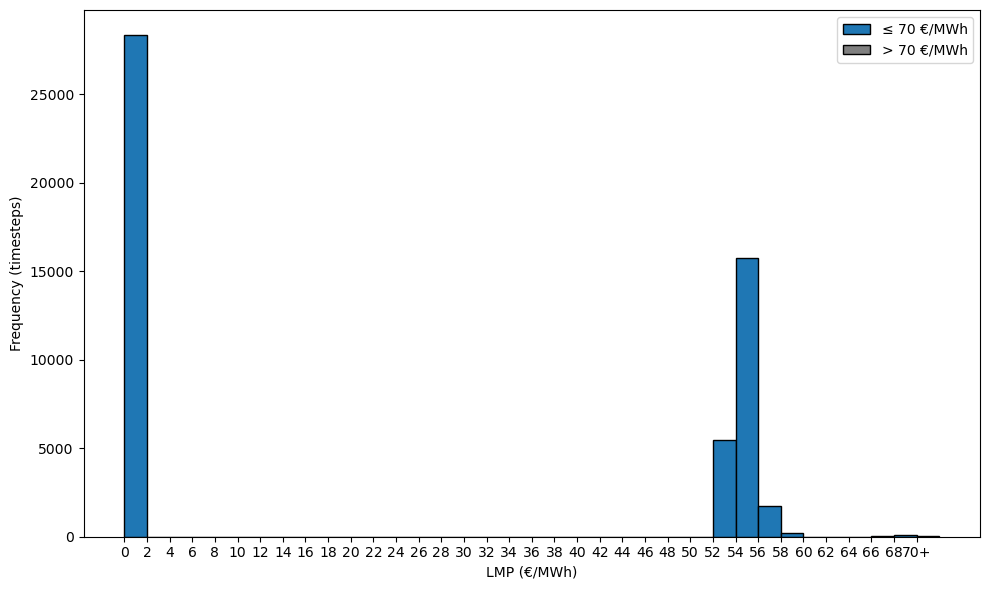

In [198]:
analytics.plot_lmp_histogram_70plus(
    power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
)

In [199]:
freq_table = analytics.make_lmp_frequency_table(
    power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    sorted_freq_table = freq_table.sort_values(by="count", ascending=False)
    display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
0,0.0,1.0,28359,54.806354,3630,4675,12480,7574
54,54.0,55.0,11998,23.187229,2168,1453,4824,3553
53,53.0,54.0,5200,10.049474,833,691,2169,1507
55,55.0,56.0,3775,7.295532,606,406,1549,1214
56,56.0,57.0,1109,2.143244,115,101,505,388
57,57.0,58.0,651,1.258117,29,28,343,251
52,52.0,53.0,266,0.514069,9,37,149,71
58,58.0,59.0,216,0.417440,2,0,121,93
68,68.0,69.0,62,0.119821,0,0,17,45
69,69.0,70.0,38,0.073438,0,0,8,30


In [200]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [201]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [202]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    27.764941
2030    20.041794
2040    23.942198
2050    37.407746
Name: dual_value, dtype: float64

In [203]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    8                1               2
     coal                    5                0               0
     offwind-ac              7                0               2
     onwind                  5                0               6
     ror                     2                0               2
     solar                   0                0              11
2030 CCGT                    9                1               1
     coal                    5                0               0
     offwind-ac              8                0               1
     onwind                  9                0               2
     ror                     4                0               0
     solar                   3                0               8
2040 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 10                0               1
     ror                     4                0               0
     solar                  11                0               0
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 11                0               0
     ror                     4                0               0
     solar                  11                0               0

In [204]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,0,0,0.000000
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,0,0,0.000000
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,1,1.315789
branch_flow_new_duals_max,89376,11818,13.222789
branch_flow_new_duals_min,89376,34992,39.151450
branch_flow_old_duals_max,89376,9566,10.703097
branch_flow_old_duals_min,89376,34992,39.151450


In [205]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                      year scenario                               
branch_extension_duals    2025 All                19              1   
                          2030 All                19              0   
                          2040 All                19              0   
                          2050 All                19              0   
branch_flow_new_duals_max 2025 NT              12768           1678   
                          2030 NT              12768           1842   
                          2040 DE              12768           1583   
                               GA              12768           1640   
                               NT              12768           1584   
                          2050 DE              12768           1726   
                               GA              12768           1765   
branch_flow_new_duals_min 2025 NT              12768           5116   
                          2030 NT              12768           4966   
                          2040 DE              12768           4986   
                               GA              12768           4952   
                               NT              12768           4982   
                          2050 DE              12768           5011   
                               GA              12768           4979   
branch_flow_old_duals_max 2025 NT              12768           1239   
                          2030 NT              12768           1397   
                          2040 DE              12768           1376   
                               GA              12768           1417   
                               NT              12768           1380   
                          2050 DE              12768           1372   
                               GA              12768           1385   
branch_flow_old_duals_min 2025 NT              12768           5116   
                          2030 NT              12768           4966   
                          2040 DE              12768           4986   
                               GA              12768           4952   
                               NT              12768           4982   
                          2050 DE              12768           5011   
                               GA              12768           4979   
emissions_duals           2025 NT                  1              0   
                          2030 NT                  1              0   
                          2040 DE                  1              0   
                               GA                  1              0   
                               NT                  1              0   
                          2050 DE                  1              0   
                               GA                  1              0   
gen_extension_duals       2025 All                51             23   
                          2030 All                51             12   
                          2040 All                51              1   
                          2050 All                51              0   
gen_output_new_duals      2025 NT              34272          20870   
                          2030 NT              34272          19193   
                          2040 DE              34272          21189   
                               GA              34272          19907   
                               NT              34272          20886   
                          2050 DE              34272          22024   
                               GA              34272          20698   
gen_output_old_duals      2025 NT              34272          20879   
                          2030 NT              34272          19220   
                          2040 DE              34272          21220   
                               GA              34272          19944   
                               NT              34272          209

In [206]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 ES1 4 offwind-ac -120356.118104
     ES1 4 onwind      -95459.879597
     PT1 1 ror         -65290.457952
     PT1 0 ror         -61522.430323
     ES1 2 onwind      -60677.157130
     ES1 6 solar       -31128.650203
     ES1 2 solar       -29001.443444
     ES1 5 solar       -28700.773315
     ES1 8 solar       -27709.529563
     PT1 0 offwind-ac  -27522.834605
     ES1 3 solar       -26142.216105
     PT1 1 solar       -25367.845330
     ES1 0 solar       -23302.591865
     ES1 7 solar       -19276.711499
     PT1 0 solar       -14858.370726
     ES1 1 onwind      -14755.242717
     ES1 4 solar       -13907.574033
     ES1 1 solar       -10534.017008
     ES1 8 onwind      -10530.338502
     ES1 6 onwind       -7533.362568
     PT1 1 onwind       -7029.987539
     ES1 7 CCGT         -1808.941459
     PT1 1 CCGT          -884.052726
2030 ES1 4 onwind      -36288.162520
     ES1 4 offwind-ac  -30474.317795
     ES1 2 onwind      -15813.023912
     ES1 6 solar        -9303.732799
     ES1 2 solar        -7888.370068
     ES1 5 solar        -7609.434011
     ES1 8 solar        -6810.134681
     PT1 1 solar        -5686.098123
     ES1 3 solar        -5574.401822
     ES1 0 solar        -3797.229946
     ES1 7 solar        -1340.374292
     ES1 7 CCGT          -684.696022
2040 ES1 4 onwind        -618.508765

In [207]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99027.729293
coal          349976.553630
offwind-ac    184196.306769
onwind         96085.888020
ror           299140.224929
solar          35602.071244
Name: capital_cost, dtype: float64